# AIVLE스쿨 2차 미니프로젝트: 신규 아파트 주차 수요 예측

<img src = "https://github.com/Jangrae/img/blob/master/parking.png?raw=true" width=800, align="left"/>

# 단계 3: 모델링

## [미션]

- 모델링을 수행합니다.
    - 전처리를 추가로 진행합니다.
    - 4개 이상의 알고리즘을 사용해 모델링을 수행합니다.
    - 각 모델에 대해 성능 튜닝을 수행합니다.
    - 성능을 비교해 최선의 모델을 선정합니다.
- 데이터 파이프라인 함수를 만듭니다.
- 새로운 데이터를 읽어와 예측을 수행합니다.

## 1. 환경설정

### (1) 로컬 수행(Anaconda)

- project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [318]:
# 기본 경로
path = ''

### (2) 구글 콜랩 수행

- 구글 콜랩을 사용중이면 구글 드라이브를 연결합니다.

In [319]:
# 구글 드라이브 연결, 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project/'

### (3) 한글 폰트 표시용 라이브러리 설치

In [320]:
# 한글 표시를 위한 라이브러리 설치
%pip install koreanize_matplotlib -q

Note: you may need to restart the kernel to use updated packages.


### (4) 라이브러리 불러오기

In [321]:
# 기본 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

# 모델링용 라이브러리 불러오기



# 기타 라이브러리 불러기기
import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (5) 데이터 불러오기

- joblib.dump() 함수를 사용해 base_data2.pkl 파일을 읽어옵니다.
- 읽어온 데이터를 data 데이터프레임으로 선언하고 기본 정보를 확인합니다.

In [322]:
# 파일 읽어오기
data = joblib.load(path+'base_data3_arch 1.pkl')

# 확인
data.head()

,총세대수,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,1인(25이하),2인(34이하),3인(43이하),4인 이상(44이상),임대보증금,임대료
0,78,2013,계단식,개별,1,109,6023.7683,0,0,0,78,5.696200e+07,642930.000000
1,35,2013,복도식,개별,1,35,1569.1668,0,35,0,0,6.306200e+07,470100.000000
2,88,2013,계단식,개별,1,88,7180.1396,0,0,0,88,7.219000e+07,586540.000000
3,477,2014,복도식,지역,1,943,47058.9273,0,0,0,477,1.015167e+08,950305.000000
4,15,2013,복도식,개별,1,21,543.0268,14,1,0,0,5.522750e+07,340148.333333


In [323]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293 entries, 0 to 344
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   총세대수         293 non-null    int64  
 1   준공연도         293 non-null    int64  
 2   건물형태         293 non-null    object 
 3   난방방식         293 non-null    object 
 4   승강기설치여부      293 non-null    int64  
 5   실차량수         293 non-null    int64  
 6   총면적          293 non-null    float64
 7   1인(25이하)     293 non-null    int64  
 8   2인(34이하)     293 non-null    int64  
 9   3인(43이하)     293 non-null    int64  
 10  4인 이상(44이상)  293 non-null    int64  
 11  임대보증금        293 non-null    float64
 12  임대료          293 non-null    float64
dtypes: float64(3), int64(8), object(2)
memory usage: 32.0+ KB


In [324]:
data.describe()

,총세대수,준공연도,승강기설치여부,실차량수,총면적,1인(25이하),2인(34이하),3인(43이하),4인 이상(44이상),임대보증금,임대료
count,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,2.930000e+02,293.000000
mean,627.692833,2007.962457,0.965870,562.931741,42023.801516,11.467577,59.959044,186.006826,370.706485,2.631197e+07,222413.619417
std,415.874003,7.534529,0.181873,379.859115,28654.971921,64.338918,190.038816,226.823343,331.840802,2.195886e+07,151812.770366
min,15.000000,1992.000000,0.000000,21.000000,543.026800,0.000000,0.000000,0.000000,0.000000,2.205000e+06,39920.000000
25%,316.000000,2003.000000,1.000000,267.000000,20297.485500,0.000000,0.000000,0.000000,88.000000,1.466833e+07,134540.000000
50%,558.000000,2009.000000,1.000000,521.000000,37424.868000,0.000000,0.000000,104.000000,316.000000,2.028225e+07,183325.000000
75%,879.000000,2014.000000,1.000000,824.000000,59574.391700,0.000000,0.000000,332.000000,558.000000,2.996200e+07,240496.666667
max,2289.000000,2022.000000,1.000000,1657.000000,150126.863200,616.000000,1479.000000,1489.000000,1445.000000,1.898219e+08,950305.000000


In [325]:

data.corr(numeric_only=True).style.background_gradient()

,총세대수,준공연도,승강기설치여부,실차량수,총면적,1인(25이하),2인(34이하),3인(43이하),4인 이상(44이상),임대보증금,임대료
총세대수,1.000000,0.052459,0.149958,0.819781,0.924575,0.107625,0.361532,0.503411,0.680599,0.076029,0.059138
준공연도,0.052459,1.000000,0.206492,0.284045,0.149656,0.208350,0.020736,-0.218686,0.166415,0.359184,0.347393
승강기설치여부,0.149958,0.206492,1.000000,0.187096,0.170884,0.021855,0.059113,-0.047147,0.182322,0.130647,0.149863
실차량수,0.819781,0.284045,0.187096,1.000000,0.924852,0.037207,0.056058,0.222064,0.838515,0.408195,0.386441
총면적,0.924575,0.149656,0.170884,0.924852,1.000000,-0.004043,0.155537,0.331557,0.846743,0.341307,0.307219
1인(25이하),0.107625,0.208350,0.021855,0.037207,-0.004043,1.000000,0.134809,-0.007651,-0.131220,-0.080564,-0.087041
2인(34이하),0.361532,0.020736,0.059113,0.056058,0.155537,0.134809,1.000000,0.000338,-0.146309,-0.137422,-0.123533
3인(43이하),0.503411,-0.218686,-0.047147,0.222064,0.331557,-0.007651,0.000338,1.000000,-0.052883,-0.213960,-0.218597
4인 이상(44이상),0.680599,0.166415,0.182322,0.838515,0.846743,-0.131220,-0.146309,-0.052883,1.000000,0.339630,0.315059
임대보증금,0.076029,0.359184,0.130647,0.408195,0.341307,-0.080564,-0.137422,-0.213960,0.339630,1.000000,0.851936


### (6) 함수 생성

- 실젯값과 모델이 예측한 값을 시각화해 비교할 함수를 만듭니다.

In [326]:
# 실젯값, 예측값 비교 함수 만들기
def model_plot(y_test, y_pred):
    plt.figure(figsize=(10, 3))
    plt.plot(y_test.values, label='Actual', linewidth=0.7, marker='o', markersize=2)
    plt.plot(y_pred, label='Predicted', linewidth=0.7, marker='o', markersize=2)
    plt.legend()
    plt.show()

## 2. 모델링

- 모델링을 위한 결측치 처리, 데이터 분할, 스케일링, 가변수화 등을 수행합니다.
- 4개 이상의 알고리즘을 사용하여 모델을 만듭니다.
- 모델 이름은 서로 다르게 합니다. (예: model1, model2...)
- Linear Regression 이외의 알고리즘을 사용한 모델은 GridSearchCV() 함수로 성능 최적화를 수행합니다.
- 적절한 평가지표로 모델의 성능을 평가합니다.
- 실젯값과 예측값을 시각화해 비교합니다.
- 성능 비교를 통해 최선의 모델을 선정합니다.

### (1) 데이터 전처리

- 필요한 전처리를 수행합니다.

#### 1) 가변수화

- '건물형태', '난방방식' 변수에 대해 가변수화를 수행합니다.

In [327]:
cols=['건물형태','난방방식']
data=pd.get_dummies(data,columns=cols,drop_first=True,dtype=int)
data


,총세대수,준공연도,승강기설치여부,실차량수,총면적,1인(25이하),2인(34이하),3인(43이하),4인 이상(44이상),임대보증금,임대료,건물형태_복도식,건물형태_혼합식,난방방식_중앙,난방방식_지역
0,78,2013,1,109,6023.7683,0,0,0,78,5.696200e+07,642930.000000,0,0,0,0
1,35,2013,1,35,1569.1668,0,35,0,0,6.306200e+07,470100.000000,1,0,0,0
2,88,2013,1,88,7180.1396,0,0,0,88,7.219000e+07,586540.000000,0,0,0,0
3,477,2014,1,943,47058.9273,0,0,0,477,1.015167e+08,950305.000000,1,0,0,1
4,15,2013,1,21,543.0268,14,1,0,0,5.522750e+07,340148.333333,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,1485,1993,1,298,64622.2500,0,1479,0,6,7.595571e+06,104975.714286,1,0,1,0
341,1386,1993,1,258,57616.8100,0,1369,0,17,8.092875e+06,111848.750000,1,0,1,0
342,956,1994,1,243,37398.7200,0,956,0,0,9.931000e+06,134540.000000,1,0,0,1
343,120,2020,1,47,5581.8024,66,54,0,0,2.515500e+06,50040.000000,1,0,0,0


#### 2) x, y 분리

- Target를 지정하고, x와 y로 분리합니다.

In [328]:
target='실차량수'
x=data.drop(columns=target)
y=data[target]
x,y

(     총세대수  준공연도  승강기설치여부         총면적  1인(25이하)  2인(34이하)  3인(43이하)  \
 0      78  2013        1   6023.7683         0         0         0   
 1      35  2013        1   1569.1668         0        35         0   
 2      88  2013        1   7180.1396         0         0         0   
 3     477  2014        1  47058.9273         0         0         0   
 4      15  2013        1    543.0268        14         1         0   
 ..    ...   ...      ...         ...       ...       ...       ...   
 340  1485  1993        1  64622.2500         0      1479         0   
 341  1386  1993        1  57616.8100         0      1369         0   
 342   956  1994        1  37398.7200         0       956         0   
 343   120  2020        1   5581.8024        66        54         0   
 344   447  1994        1  19383.4100         0       447         0   
 
      4인 이상(44이상)         임대보증금            임대료  건물형태_복도식  건물형태_혼합식  난방방식_중앙  \
 0             78  5.696200e+07  642930.000000         0         0 

#### 3) 학습용, 평가용 분리

- 학습용, 평가용 데이터를 적절한 비율로 분리합니다.

In [329]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

#### 4) 스케일링

- 필요한 경우 스케일링을 진행합니다.
- 예를 들어 KNN 알고리즘을 사용할 경우입니다.

In [330]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
x_train_s=scaler.fit_transform(x_train)
x_test_s=scaler.transform(x_test)

In [331]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error


In [332]:
temp={}

### (2) 모델 1: 알고리즘

0.7920466917105714


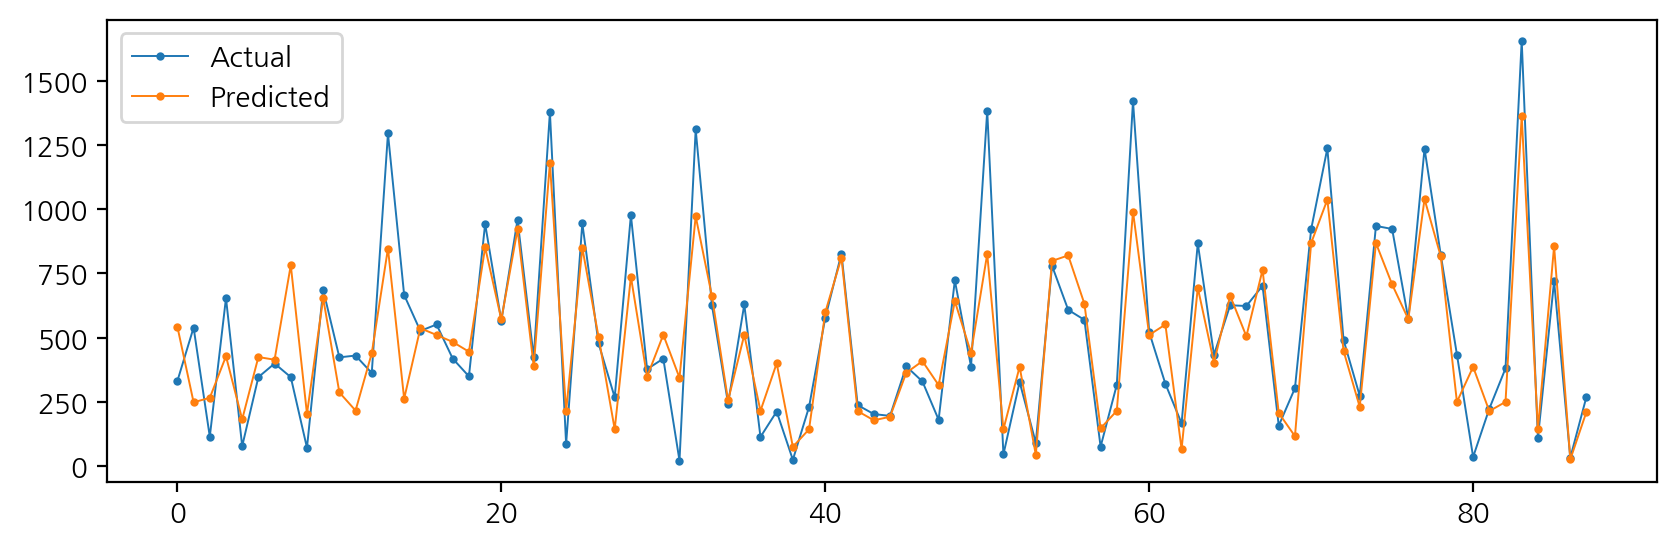

In [333]:
model = KNeighborsRegressor()
model.fit(x_train_s,y_train)
y_pred=model.predict(x_test_s)
print(r2_score(y_test,y_pred))
temp['KNN']=r2_score(y_test,y_pred)
model_plot(y_test,y_pred)

### (3) 모델 2: 알고리즘


0.9050505789321593 81.81513347763348


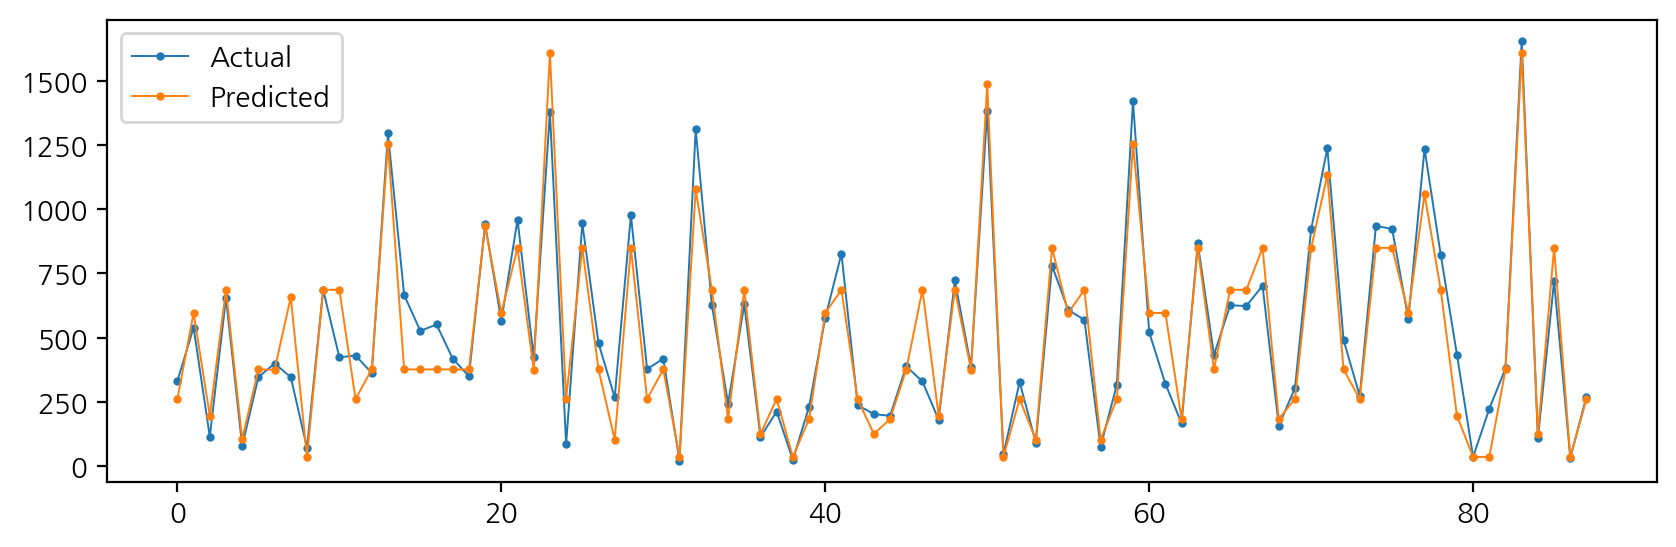

In [334]:
model = DecisionTreeRegressor(max_depth=5)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(r2_score(y_test,y_pred),mean_absolute_error(y_test,y_pred))
temp['DecisionTree']=r2_score(y_test,y_pred)
model_plot(y_test,y_pred)

### (4) 모델 3: 알고리즘

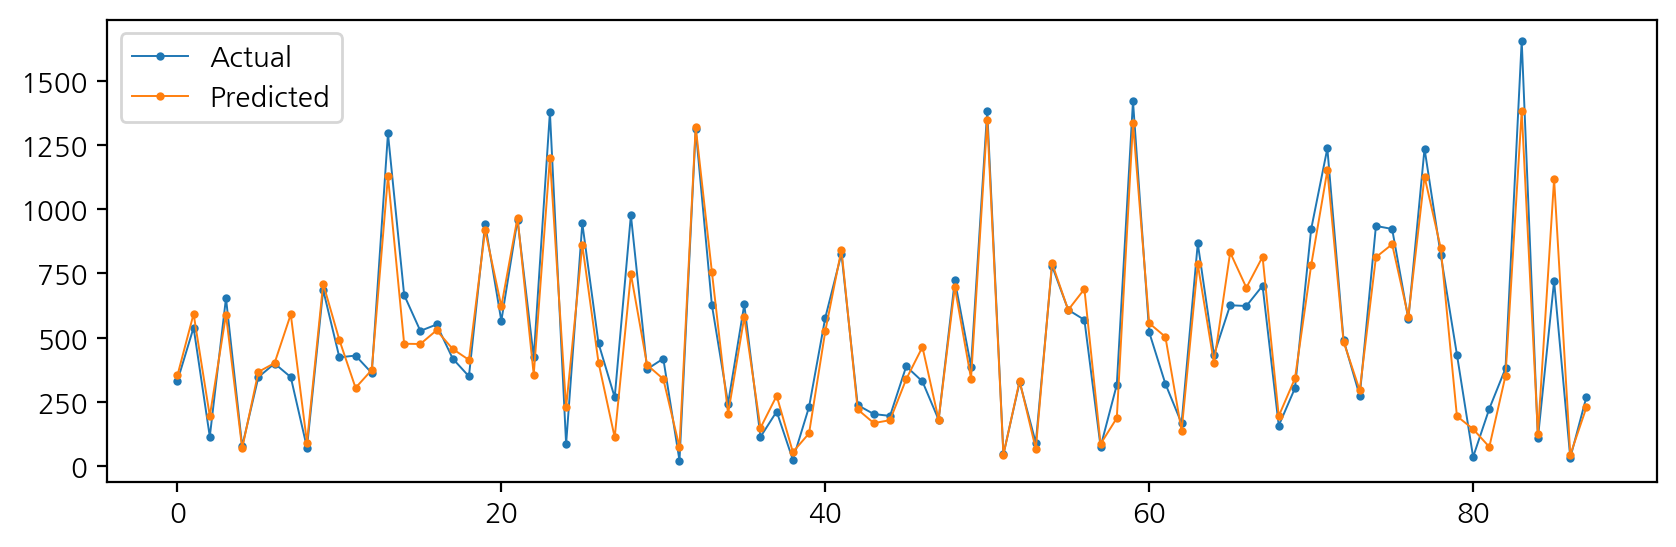

In [335]:
model=LGBMRegressor(max_depth=5,n_estimators=100)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2_score(y_test,y_pred)
temp['lightgbm']=r2_score(y_test,y_pred)
model_plot(y_test,y_pred)

### (5) 모델 4: 알고리즘

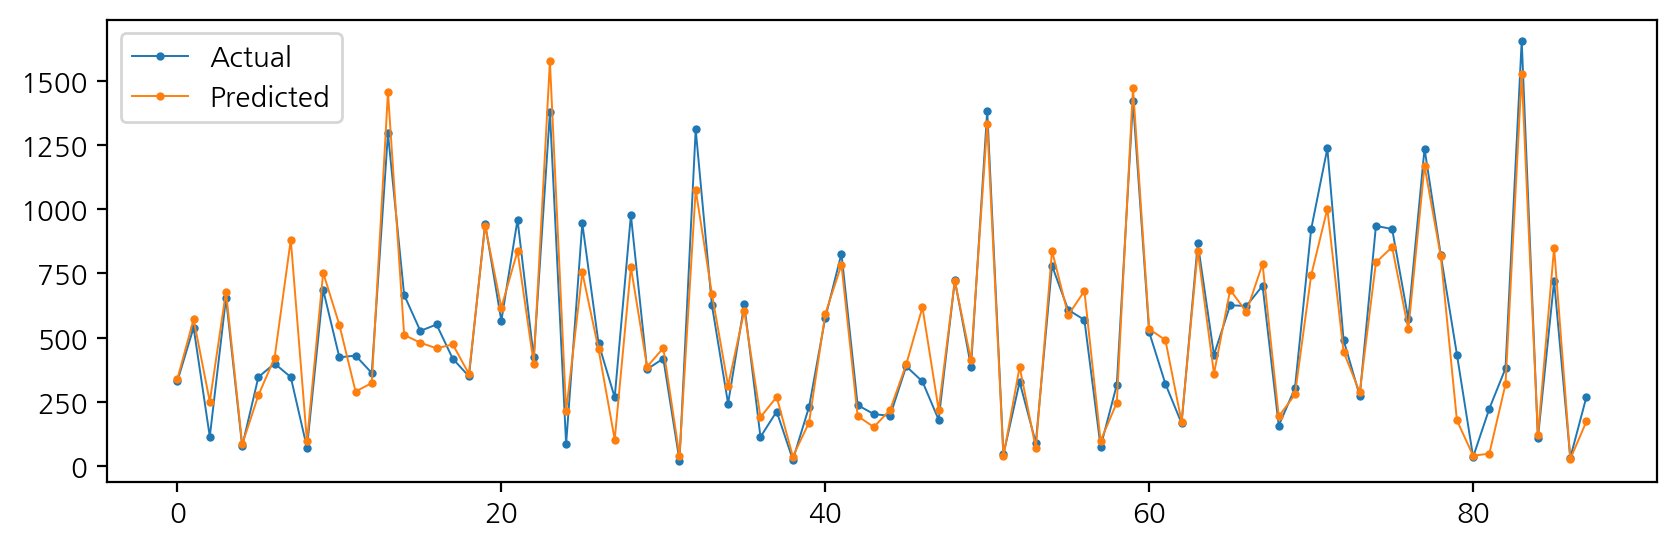

In [336]:
model = XGBRegressor()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2_score(y_test,y_pred)
temp['XGB']=r2_score(y_test,y_pred)
model_plot(y_test,y_pred)

### (6) 모델 5: 알고리즘

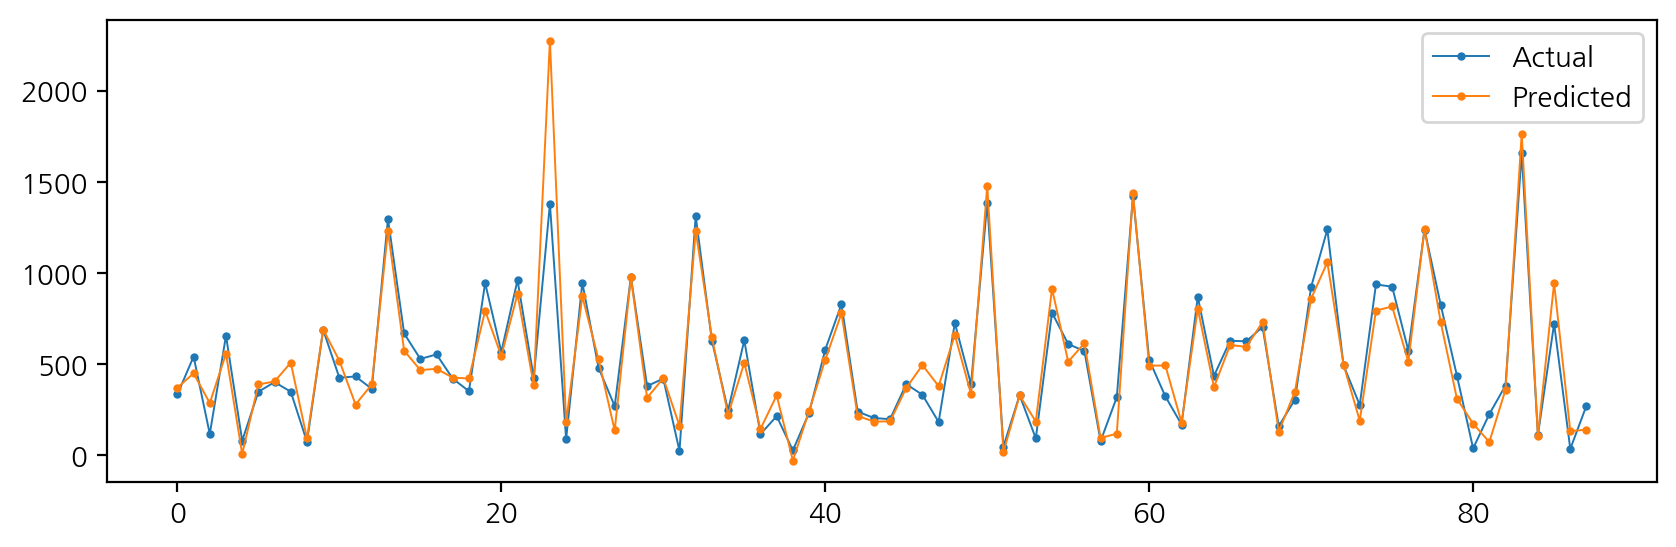

In [337]:
model = LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2_score(y_test,y_pred)
temp['linear']=r2_score(y_test,y_pred)
model_plot(y_test,y_pred)

### (7) 모델 6: 알고리즘

67.87866568914956
0.9256916640893454


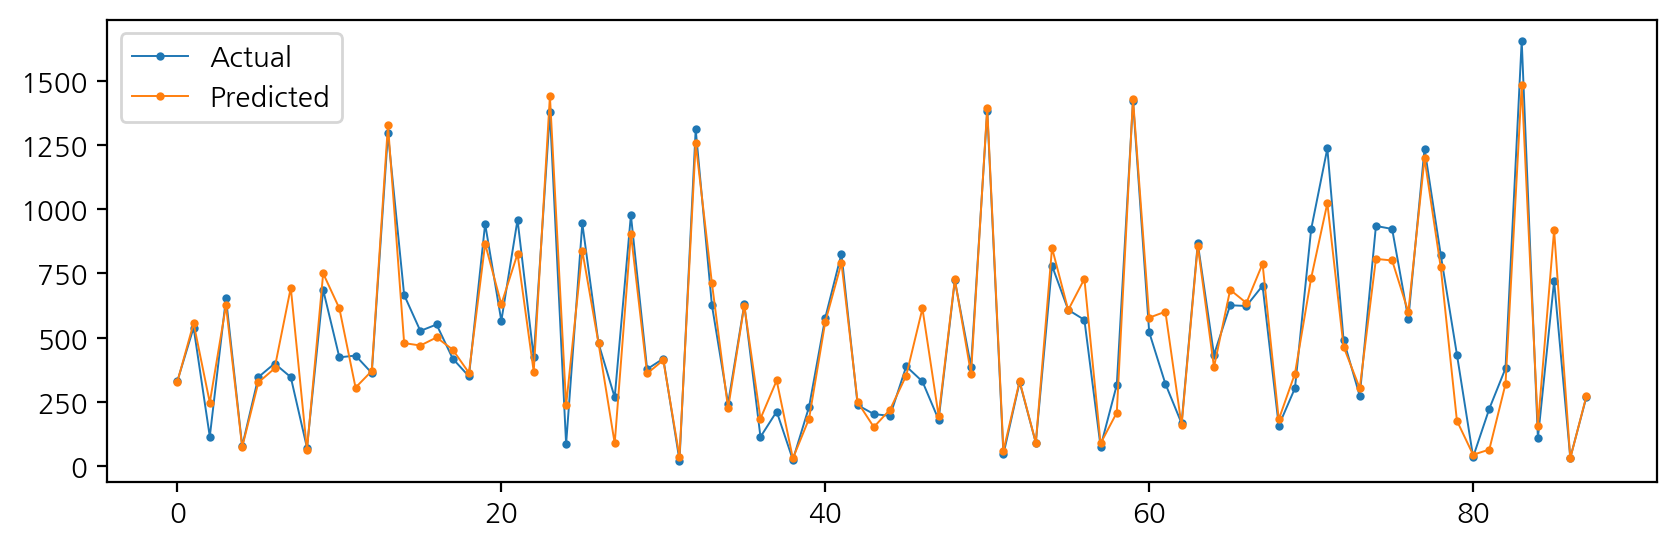

In [338]:
model = RandomForestRegressor(max_depth = 47,n_estimators=31)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))
temp['RandomForest']=r2_score(y_test,y_pred)
model_plot(y_test,y_pred)

### (8) 성능 비교

- 각 모델의 성능을 비교합니다.

In [339]:
temp

{'KNN': 0.7920466917105714,
 'DecisionTree': 0.9050505789321593,
 'lightgbm': 0.9232596807296856,
 'XGB': 0.9078360430643052,
 'linear': 0.8741900507770983,
 'RandomForest': 0.9256916640893454}

In [340]:
max(temp.values())


0.9256916640893454

#### 모델링 커스텀 ( GRIDSEARCHCV)

In [342]:
from sklearn.model_selection import GridSearchCV
params ={
    'max_depth' : range(1,50,1), 
    'n_estimators' : range(1,100,10)
 }

model_r=GridSearchCV(RandomForestRegressor(),param_grid=params)
model_r.fit(x_train,y_train)
model_r.best_score_,model_r.best_params_

(0.8620392019584286, {'max_depth': 36, 'n_estimators': 11})

In [343]:
params ={
    'max_depth' : range(1,50,1)
 }

model_d=GridSearchCV(DecisionTreeRegressor(),param_grid=params)
model_d.fit(x_train,y_train)
model_d.best_score_,model_d.best_params_

(0.8064552851819322, {'max_depth': 5})

In [344]:
params ={
    'n_neighbors' : range(1,200,1)
 }

model_k=GridSearchCV(KNeighborsRegressor(),param_grid=params)
model_k.fit(x_train,y_train)
model_k.best_score_,model_k.best_params_

KeyboardInterrupt: 

In [305]:
params ={
    'max_depth' : range(1,50,1), 
    'n_estimators' : range(1,100,10)
 }

model_x=GridSearchCV(XGBRegressor(),param_grid=params)
model_x.fit(x_train,y_train)
model_x.best_score_,model_x.best_params_

(0.8788993694240979, {'max_depth': 4, 'n_estimators': 51})

In [306]:
params ={
    'max_depth' : range(1,50,1), 
    'n_estimators' : range(1,100,10)
 }

model_l=GridSearchCV(LGBMRegressor(),param_grid=params)
model_l.fit(x_train,y_train)
model_l.best_score_,model_l.best_params_

(0.8782099217036029, {'max_depth': 4, 'n_estimators': 71})

## 3. 파이프라인 구축

- 새로운 데이터를 불러오고, 이 데이터를 처리할 파이프라인 함수를 만듭니다.

### (1) New Data 불러오기

- test.xlsx 파일을 읽어와 new_data 데이터프레임으로 선언합니다.
- 해당 데이터는 '실차량수' 변수가 없는 것 외에는, 최초 데이터와 동일한 구조입니다.
- 이 데이터를 대상으로 전처리와 예측을 수행합니다.

In [351]:
# 파일 읽어오기
new_data = pd.read_excel(path+'test.xlsx')

# 확인
new_data

,단지코드,단지명,총세대수,전용면적별세대수,지역,준공일자,건물형태,난방방식,승강기설치여부,단지내주차면수,전용면적,공용면적,임대보증금,임대료
0,C0005,서울석촌 도시형주택(공임10년),20,6,서울,20121115,복도식,개별가스난방,전체동 설치,9,17.53,11.7251,50449000,263710
1,C0005,서울석촌 도시형주택(공임10년),20,10,서울,20121115,복도식,개별가스난방,전체동 설치,9,24.71,16.5275,52743000,321040
2,C0005,서울석촌 도시형주택(공임10년),20,4,서울,20121115,복도식,개별가스난방,전체동 설치,9,26.72,17.8720,53890000,332510
3,C0017,대구혁신센텀힐즈,822,228,대구경북,20180221,계단식,지역난방,NaN,824,51.87,20.9266,29298000,411200
4,C0017,대구혁신센텀힐즈,822,56,대구경북,20180221,계단식,지역난방,NaN,824,59.85,24.1461,38550000,462600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,C0353,대전판암3,768,90,대전충남,19910805,복도식,중앙난방,전체동 설치,142,40.32,16.5100,8848000,122290
100,C0360,하남미사 A26BL,588,98,서울,20160901,NaN,지역난방,NaN,539,51.37,21.5569,183228000,0
101,C0360,하남미사 A26BL,588,186,서울,20160901,NaN,지역난방,NaN,539,51.39,21.5652,183228000,0
102,C0360,하남미사 A26BL,588,102,서울,20160901,NaN,지역난방,NaN,539,59.76,25.0776,215057000,0


### (2) 데이터 파이프라인 구축

- 데이터 파이프라인 함수를 만듭니다.
- 학습 데이터에 대해 진행했던 모든 전처리 과정을 평가 데이터에도 일괄 진행해야 합니다.
    - 입력: new_data
    - 출력: 전처리가 완료된 예측 직전 데이터프레임
- 새로운 데이터에는 '실차량수' 변수가 없음을 유의합니다.
- 참고: 다음 내용들이 처리되어야 합니다.
    - 결측치 처리
    - 변수 추가
    - 불필요한 변수 제거
    - 단지 데이터, 상세 데이터 분리
    - 단지코드별 총면적 합 집계
    - 전용면적 구간별 집계 (피벗 형태)
    - 임대보증금, 임대료 평균 집계
    - 집계 결과 병합
    - 난방방식: 개별, 지역, 중앙 세 가지로 묶기
    - 승강기설치여부: 0, 1 값으로 변경
    - 단지모드, 지역 변수 제거
    - 가변수화

In [352]:
# 파이프라인 만들기
def data_pipeline(data):
    apt01 = data.copy()
    
    
    ### 1. 전처리 ###
    # 결측치 처리 #
    na_cols = ['건물형태', '난방방식', '승강기설치여부']
    for col in na_cols:
        apt01.loc[apt01[col].isna(), col] = apt01[col].mode()[0]
    # 변수 추가 #
    apt01['준공연도'] = apt01['준공일자'] // 10000
    apt01['총면적'] = (apt01['전용면적'] + apt01['공용면적']) * apt01['전용면적별세대수']
    # 불필요 변수 제거 #
    del_cols = ['단지명', '단지내주차면수', '준공일자']
    apt01.drop(columns=del_cols, inplace=True)
    
    
    ### 2. 데이터 분리 ###
    # data01 분리 #
    cols = ['단지코드', '총세대수', '지역', '준공연도', '건물형태', '난방방식', '승강기설치여부']
    data01 = apt01.loc[:, cols]
    data01.drop_duplicates(inplace=True)
    data01.reset_index(drop=True, inplace=True)
    cols = ['단지코드', '총면적', '전용면적별세대수', '전용면적', '공용면적', '임대보증금', '임대료']
    data02 = apt01.loc[:, cols]
    df_area = data02.groupby(by='단지코드', as_index=False)[['총면적']].sum()
    
    ## 범위 부분이라 추후 결론 짓는 대로 바꿔야 함##
    apart_area_bin = [0, 25, 34, 43, 200]
    apart_area_label = ['1인(25이하)', '2인(34이하)', '3인(43이하)', '4인 이상(44이상)']
    
    # data02 분리 #
    data02['전용면적구간'] = pd.cut(data02['전용면적'], bins=apart_area_bin, labels=apart_area_label)
    temp = data02.groupby(by=['단지코드', '전용면적구간'], as_index=False)['전용면적별세대수'].sum()
    df_pivot = temp.pivot(index='단지코드', columns='전용면적구간', values='전용면적별세대수')
    df_pivot.reset_index(inplace=True)
    df_pivot.columns.name=None
    df_rent = data02.groupby(by='단지코드', as_index=False)[['임대보증금', '임대료']].mean()
    
    
    
    ### 3. 데이터 합치기 ###
    apart = pd.merge(data01, df_area, how='left', on='단지코드')
    apart = pd.merge(apart, df_pivot, how='left', on='단지코드')
    apart = pd.merge(apart, df_rent, how='left', on='단지코드')

    ### 4. 추가 전처리 ###
    apart['난방방식'] = apart['난방방식'].map({'개별가스난방': '개별', '개별유류난방': '개별',
                   '지역난방': '지역', '지역가스난방': '지역', '지역유류난방': '지역',
                   '중앙가스난방': '중앙', '중앙난방': '중앙', '중앙유류난방': '중앙'})
    apart['승강기설치여부'] = apart['승강기설치여부'].map({'전체동 설치': 1, '일부동 설치': 0, '미설치': 0})
    apart.drop(columns=['단지코드', '지역'], inplace=True)
    return apart

    

### (3) 예측하기

- new_data를 파이프라인을 사용해 전처리한 후 가장 성능이 좋았던 모델로 예측한 결과를 확인합니다.

In [353]:
# 데이터 전처리
data = data_pipeline(new_data)

# 확인
data

,총세대수,준공연도,건물형태,난방방식,승강기설치여부,총면적,1인(25이하),2인(34이하),3인(43이하),4인 이상(44이상),임대보증금,임대료
0,20,2012,복도식,개별,1,766.2736,16,4,0,0,5.236067e+07,305753.333333
1,822,2018,계단식,지역,1,31396.0944,0,0,0,404,3.546600e+07,445466.666667
2,112,2014,계단식,지역,1,12450.4308,0,0,0,112,9.869750e+07,744450.000000
3,122,2011,계단식,지역,1,13081.4772,0,0,0,122,0.000000e+00,0.000000
4,262,2011,계단식,지역,1,28141.7516,0,0,0,262,0.000000e+00,0.000000
5,35,2001,계단식,개별,1,3379.7260,0,0,0,35,0.000000e+00,0.000000
6,47,2009,계단식,개별,1,5154.6660,0,0,0,47,0.000000e+00,0.000000
7,152,2008,계단식,지역,1,17049.8200,0,0,0,152,0.000000e+00,0.000000
8,73,2005,계단식,지역,1,7845.7626,0,0,0,73,0.000000e+00,0.000000
9,571,1998,복도식,지역,1,33959.3318,0,0,268,303,1.670100e+07,215150.000000


In [354]:
cols=['건물형태','난방방식']
data=pd.get_dummies(data,columns=cols,drop_first=True,dtype=int)
data

,총세대수,준공연도,승강기설치여부,총면적,1인(25이하),2인(34이하),3인(43이하),4인 이상(44이상),임대보증금,임대료,건물형태_복도식,건물형태_혼합식,난방방식_중앙,난방방식_지역
0,20,2012,1,766.2736,16,4,0,0,5.236067e+07,305753.333333,1,0,0,0
1,822,2018,1,31396.0944,0,0,0,404,3.546600e+07,445466.666667,0,0,0,1
2,112,2014,1,12450.4308,0,0,0,112,9.869750e+07,744450.000000,0,0,0,1
3,122,2011,1,13081.4772,0,0,0,122,0.000000e+00,0.000000,0,0,0,1
4,262,2011,1,28141.7516,0,0,0,262,0.000000e+00,0.000000,0,0,0,1
5,35,2001,1,3379.7260,0,0,0,35,0.000000e+00,0.000000,0,0,0,0
6,47,2009,1,5154.6660,0,0,0,47,0.000000e+00,0.000000,0,0,0,0
7,152,2008,1,17049.8200,0,0,0,152,0.000000e+00,0.000000,0,0,0,1
8,73,2005,1,7845.7626,0,0,0,73,0.000000e+00,0.000000,0,0,0,1
9,571,1998,1,33959.3318,0,0,268,303,1.670100e+07,215150.000000,1,0,0,1


In [355]:
model_f=RandomForestRegressor(max_depth=44,n_estimators=11)
model_f.fit(x_train,y_train)
y_pred = model_f.predict(x_test)
 
 
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))
temp['RandomForest']=r2_score(y_test,y_pred)

67.45661157024793
0.9355330658039086


In [356]:
# 예측하기
predicted = model_f.predict(data)

# 확인
print(predicted)

[  51.54545455  539.27272727  317.18181818  172.54545455  266.09090909
   48.63636364   60.72727273  186.27272727  119.63636364  410.36363636
  297.18181818   58.45454545 1412.81818182  639.45454545  673.54545455
  773.09090909  638.18181818   53.63636364  951.63636364  946.
  279.09090909  817.54545455  764.72727273  815.81818182  974.81818182
  227.72727273   69.36363636 1184.          229.27272727  868.54545455]


- 아파트 기본 정보에 예측한 차량수를 붙여 마무리합니다.

In [357]:
# 데이터 셋 두개로 나누기
vars = ['단지코드', '단지명', '총세대수', '지역']
result = new_data[vars].copy()
result = result.drop_duplicates()
result.reset_index(drop=True, inplace=True)

# 예측 결과 추가
result['예상차량수'] = predicted.round(1).astype(int)
5
# 확인
result

,단지코드,단지명,총세대수,지역,예상차량수
0,C0005,서울석촌 도시형주택(공임10년),20,서울,51
1,C0017,대구혁신센텀힐즈,822,대구경북,539
2,C0034,광교 호반마을 22단지 아파트,112,경기,317
3,C0046,죽미마을 휴먼시아12단지,122,경기,172
4,C0055,파주운정 한울마을 6단지,262,경기,266
5,C0072,벌교제석휴먼시아,35,광주전남,48
6,C0073,무안남악오룡마을,47,광주전남,60
7,C0084,진해 석동우림필유 아파트,152,경남,186
8,C0085,김해북부 두산위브 아파트,73,경남,119
9,C0112,운암주공6단지아파트,571,경기,410


In [362]:
def plot_scatter(data, column):
    plt.figure(figsize=(10, 6))
    sns.regplot(x=data[column], y=data['예상차량수'],line_kws={"color": "red"})
    plt.title(f"{column} vs 예상차량수")
    plt.xlabel(column)
    plt.ylabel('예상차량수')
    plt.show()

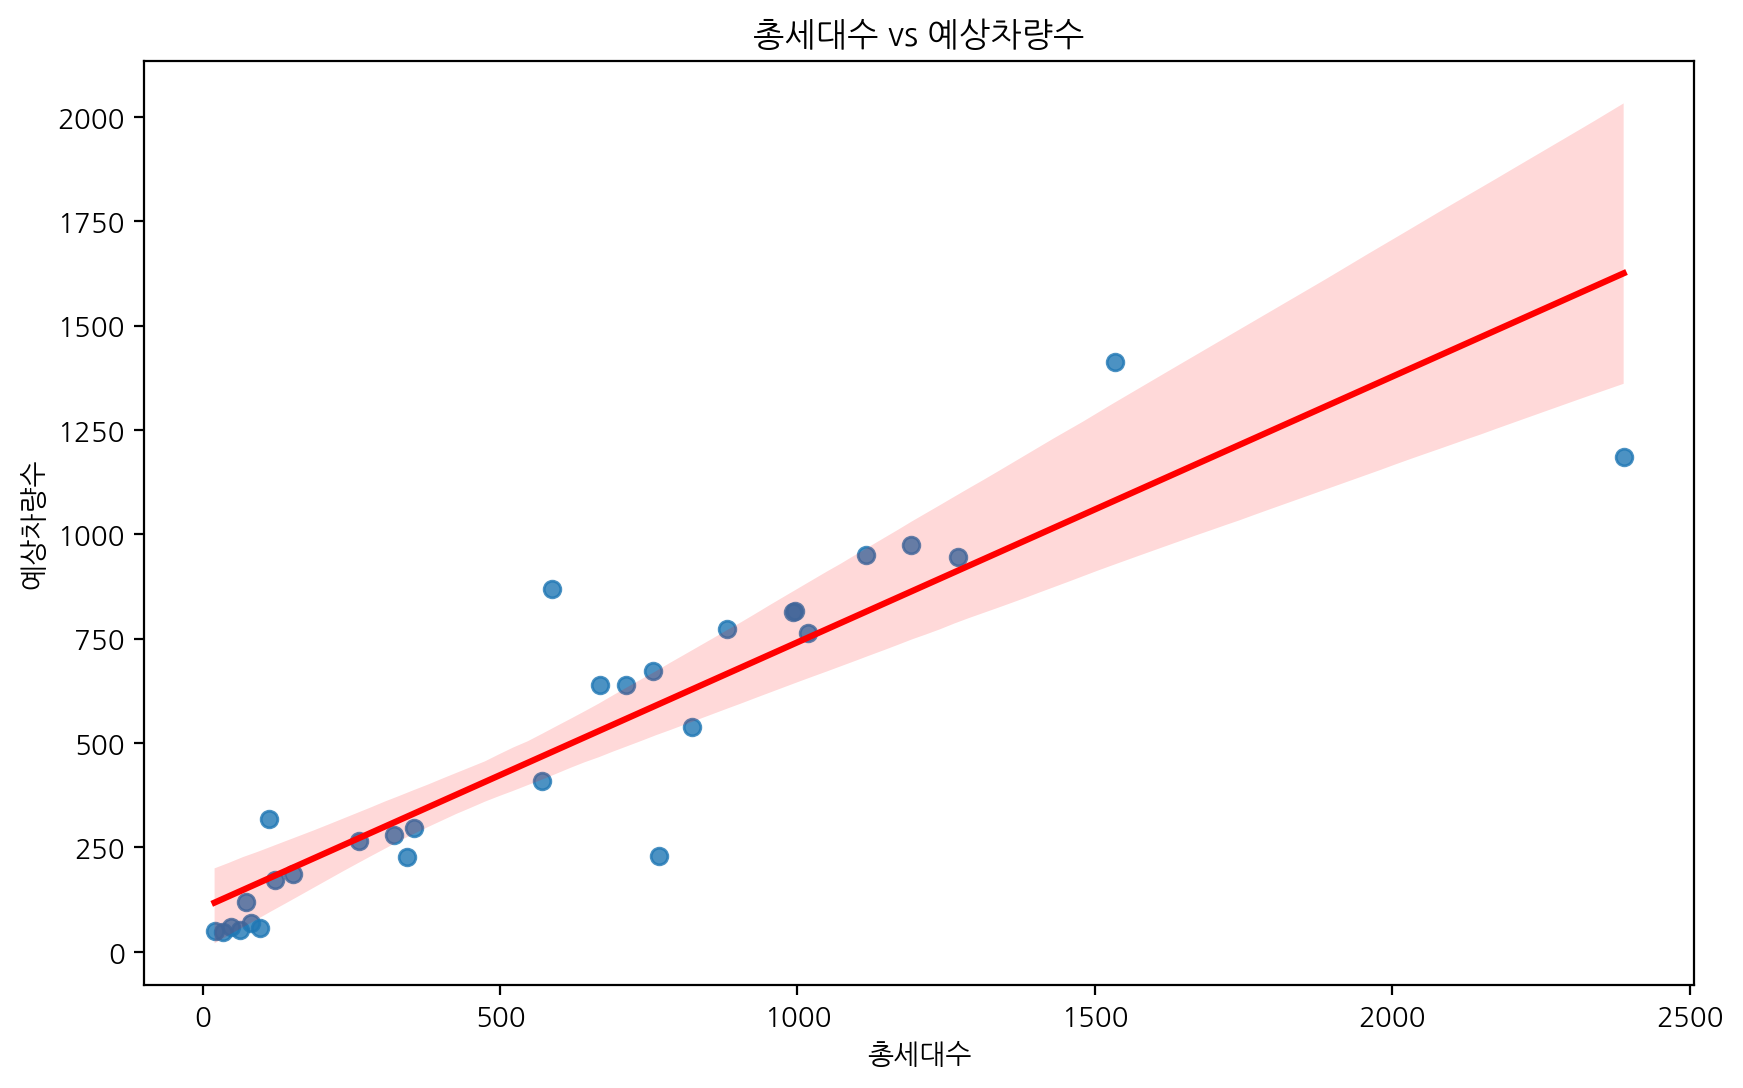

In [363]:
plot_scatter(result,'총세대수')